In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/camnugent/sandp500/merge.sh
/kaggle/input/datasets/camnugent/sandp500/getSandP.py
/kaggle/input/datasets/camnugent/sandp500/all_stocks_5yr.csv
/kaggle/input/datasets/camnugent/sandp500/individual_stocks_5yr/__MACOSX/individual_stocks_5yr/._.DS_Store
/kaggle/input/datasets/camnugent/sandp500/individual_stocks_5yr/__MACOSX/individual_stocks_5yr/._ABC_data.csv
/kaggle/input/datasets/camnugent/sandp500/individual_stocks_5yr/__MACOSX/individual_stocks_5yr/._AAPL_data.csv
/kaggle/input/datasets/camnugent/sandp500/individual_stocks_5yr/__MACOSX/individual_stocks_5yr/._A_data.csv
/kaggle/input/datasets/camnugent/sandp500/individual_stocks_5yr/__MACOSX/individual_stocks_5yr/._MAS_data.csv
/kaggle/input/datasets/camnugent/sandp500/individual_stocks_5yr/individual_stocks_5yr/CL_data.csv
/kaggle/input/datasets/camnugent/sandp500/individual_stocks_5yr/individual_stocks_5yr/FDX_data.csv
/kaggle/input/datasets/camnugent/sandp500/individual_stocks_5yr/individual_stocks_5yr/AMAT_

# 📈 Stock Price Prediction using ARIMA & LSTM

## 🔍 Problem Statement
The goal of this project is to predict future stock closing prices using historical stock market data by applying both statistical and deep learning approaches.


##  Objectives
- Analyze stock price trends
- Check stationarity of time-series data
- Implement ARIMA as baseline model
- Build LSTM deep learning model
- Compare performance using RMSE
- Implement future price prediction

In [2]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

E0000 00:00:1772434680.288524      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772434680.358964      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772434680.903960      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772434680.904008      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772434680.904012      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772434680.904016      17 computation_placer.cc:177] computation placer already registered. Please check linka

#  Data Collection

In [3]:
df = pd.read_csv("/kaggle/input/datasets/camnugent/sandp500/individual_stocks_5yr/individual_stocks_5yr/IBM_data.csv")
df.head(20)

,date,open,high,low,close,volume,Name
0,2013-02-08,199.97,202.090,199.68,201.68,2893254,IBM
1,2013-02-11,200.98,201.950,199.75,200.16,2944651,IBM
2,2013-02-12,200.01,200.735,199.02,200.04,2461779,IBM
3,2013-02-13,200.65,200.950,199.57,200.09,2169757,IBM
4,2013-02-14,199.73,200.320,199.26,199.65,3294126,IBM
5,2013-02-15,199.98,201.250,199.82,200.98,3627887,IBM
6,2013-02-19,200.60,201.890,200.22,200.32,2998317,IBM
7,2013-02-20,200.62,201.720,198.86,199.31,3715311,IBM
8,2013-02-21,198.63,199.070,198.11,198.33,3923051,IBM
9,2013-02-22,199.23,201.090,198.84,201.09,3107876,IBM


#  Data Cleaning
- Handle missing values
- Set business-day frequency

In [4]:
# Convert date column
df['date'] = pd.to_datetime(df['date'])

# Filter only one stock (IBM)
df = df[df['Name'] == "IBM"]

# Sort by date
df = df.sort_values("date")

# Set index
df.set_index("date", inplace=True)

df.head()

,open,high,low,close,volume,Name
date,,,,,,
2013-02-08,199.97,202.090,199.68,201.68,2893254,IBM
2013-02-11,200.98,201.950,199.75,200.16,2944651,IBM
2013-02-12,200.01,200.735,199.02,200.04,2461779,IBM
2013-02-13,200.65,200.950,199.57,200.09,2169757,IBM
2013-02-14,199.73,200.320,199.26,199.65,3294126,IBM


**Use Only Close Price**

In [5]:
data = df[['close']]

#  Exploratory Data Analysis (EDA)

# Plot Closing Price

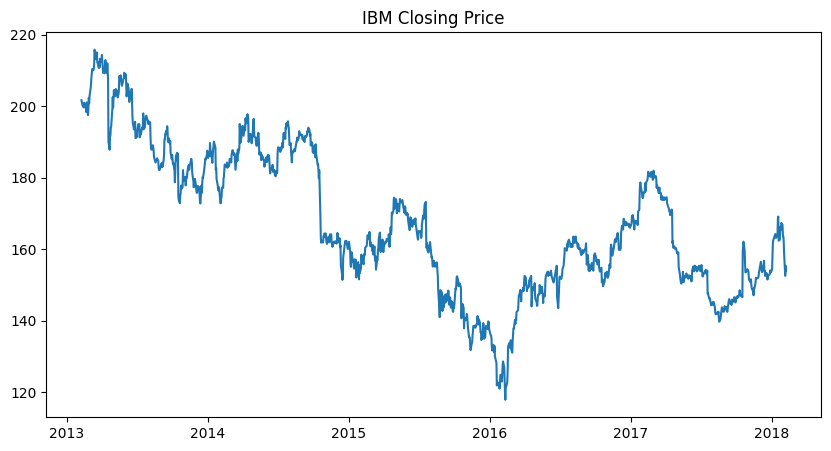

In [6]:
plt.figure(figsize=(10,5))
plt.plot(data['close'])
plt.title("IBM Closing Price")
plt.show()

# ARIMA SECTION

# Stationarity Check

In [7]:
result = adfuller(data['close'])
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -2.0837019363172815
p-value: 0.25111843181985416


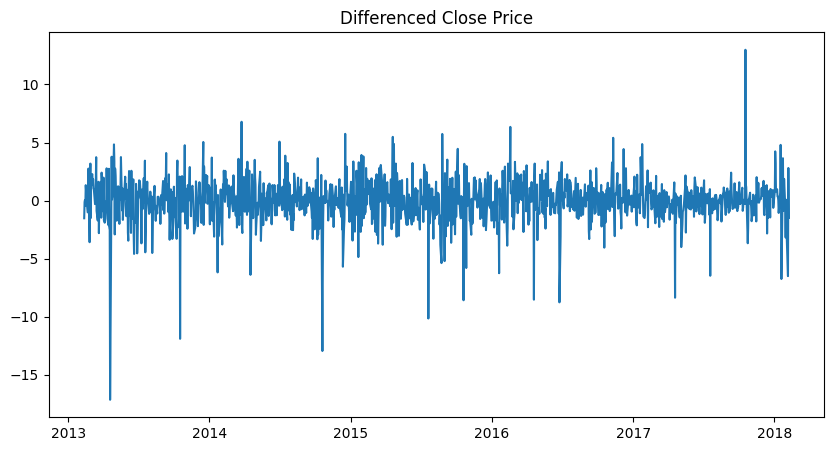

In [8]:
data_diff = data['close'].diff().dropna()

plt.figure(figsize=(10,5))
plt.plot(data_diff)
plt.title("Differenced Close Price")
plt.show()

In [9]:
result_diff = adfuller(data_diff)

print("ADF Statistic After Differencing:", result_diff[0])
print("p-value After Differencing:", result_diff[1])

ADF Statistic After Differencing: -25.742789289522317
p-value After Differencing: 0.0


# Train ARIMA

<Figure size 1200x500 with 0 Axes>

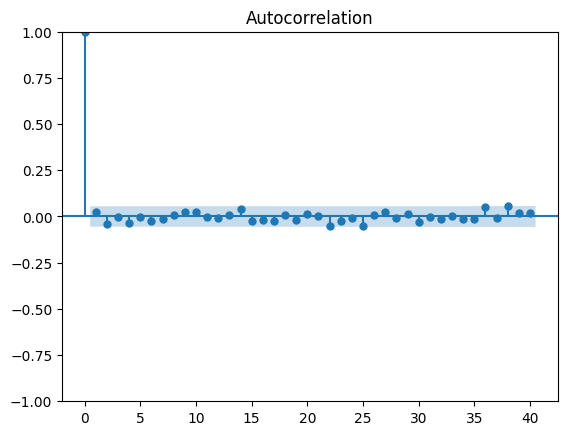

<Figure size 1200x500 with 0 Axes>

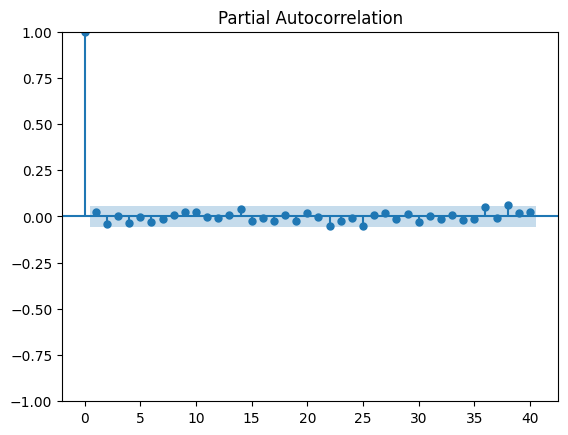

In [10]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(12,5))
plot_acf(data_diff, lags=40)
plt.show()

plt.figure(figsize=(12,5))
plot_pacf(data_diff, lags=40)
plt.show()

In [11]:
train_size = int(len(data) * 0.8)
train = data[:train_size]
test = data[train_size:]

model_arima = ARIMA(train, order=(1,1,1))
model_fit = model_arima.fit()

predictions = model_fit.forecast(steps=len(test))

rmse_arima = np.sqrt(mean_squared_error(test, predictions))
print("ARIMA RMSE:", rmse_arima)

ARIMA RMSE: 24.540426515244796


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p


1. 👉 On average, prediction error ≈ ₹24.5
2. 👉 For stock price around 150–200 range, this is normal
3. 👉 Stock forecasting is naturally difficult


So model is working fine

# Fix This Properly (Professional Way)

In [12]:
data = data.asfreq('B')   # Set business day frequency
data = data.ffill()       # Forward fill missing values

# Prepare Data for LSTM

In [13]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data[['close']])

# Create Sequences (60 Days Window)

In [14]:
X, y = [], []

for i in range(60, len(scaled_data)):
    X.append(scaled_data[i-60:i])
    y.append(scaled_data[i])

X = np.array(X)
y = np.array(y)

# Train-Test Split

In [15]:
split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

# Strong LSTM Model

In [16]:
model_lstm = Sequential()

model_lstm.add(LSTM(64, return_sequences=True, input_shape=(60,1)))
model_lstm.add(Dropout(0.2))

model_lstm.add(LSTM(64))
model_lstm.add(Dropout(0.2))

model_lstm.add(Dense(1))

model_lstm.compile(optimizer='adam', loss='mse')

history = model_lstm.fit(X_train, y_train,
                         epochs=25,
                         batch_size=32,
                         validation_data=(X_test, y_test))

Epoch 1/25


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - loss: 0.0720 - val_loss: 0.0022
Epoch 2/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 0.0053 - val_loss: 0.0017
Epoch 3/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0045 - val_loss: 0.0014
Epoch 4/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.0037 - val_loss: 0.0024
Epoch 5/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.0039 - val_loss: 0.0015
Epoch 6/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0042 - val_loss: 0.0018
Epoch 7/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0039 - val_loss: 0.0013
Epoch 8/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.0033 - val_loss: 0.0011
Epoch 9/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.0032 - val_loss: 0.0012
Epoch 10/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.0033 - val_loss: 0.0011
Epoch 11/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.0031 - val_loss: 0.0011
Epoch 12/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.0030 - val_l

# Prediction

In [17]:
predictions = model_lstm.predict(X_test)

predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step


# Calculate RMSE

In [18]:
rmse_lstm = np.sqrt(mean_squared_error(y_test_actual, predictions))
print("LSTM RMSE:", rmse_lstm)

LSTM RMSE: 2.786409300284575


If LSTM < 24.54

1. 👉 LSTM is better than ARIMA
2. 👉 You can confidently conclude deep learning performs better.


# Plot Actual vs Predicted

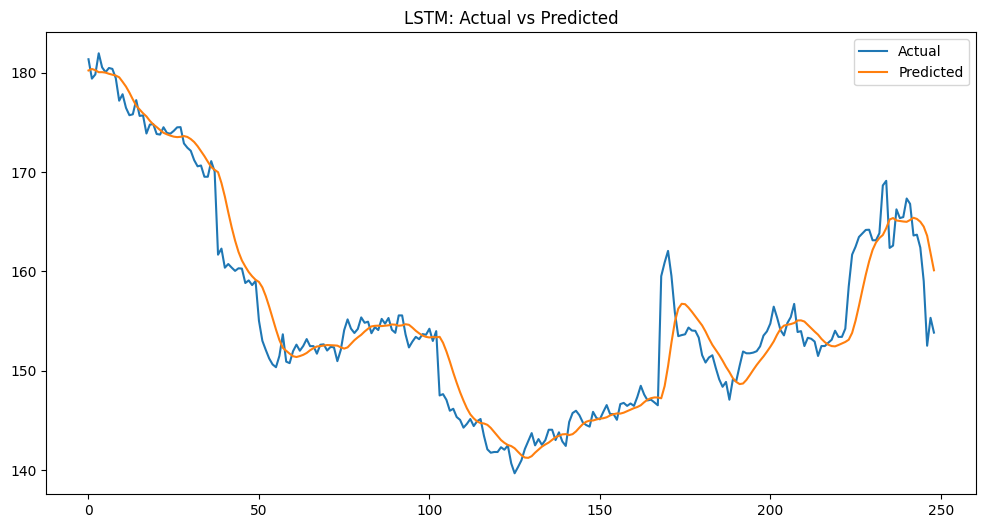

In [19]:
plt.figure(figsize=(12,6))
plt.plot(y_test_actual, label="Actual")
plt.plot(predictions, label="Predicted")
plt.legend()
plt.title("LSTM: Actual vs Predicted")
plt.show()

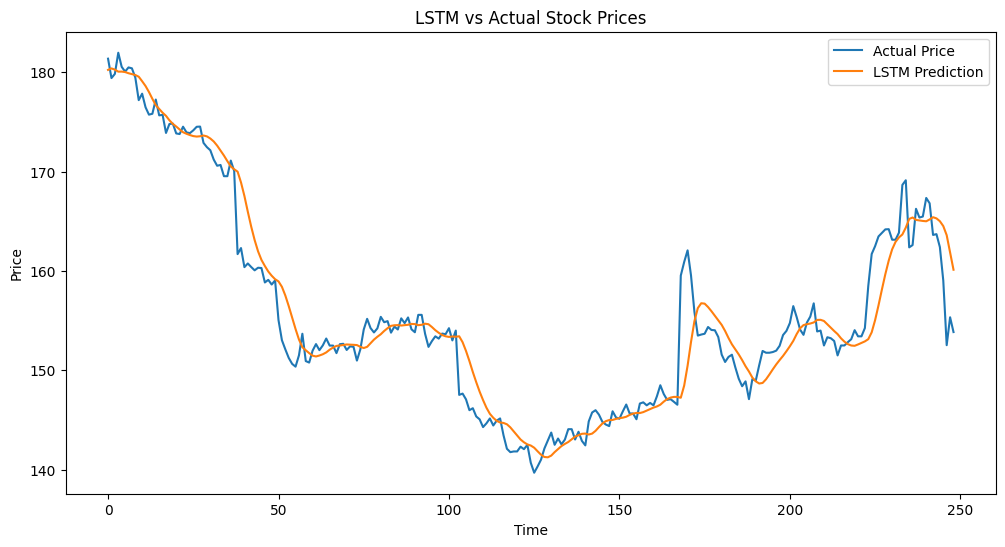

In [20]:
plt.figure(figsize=(12,6))
plt.plot(y_test_actual, label="Actual Price")
plt.plot(predictions, label="LSTM Prediction")
plt.title("LSTM vs Actual Stock Prices")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()

# Add ARIMA vs LSTM Plot

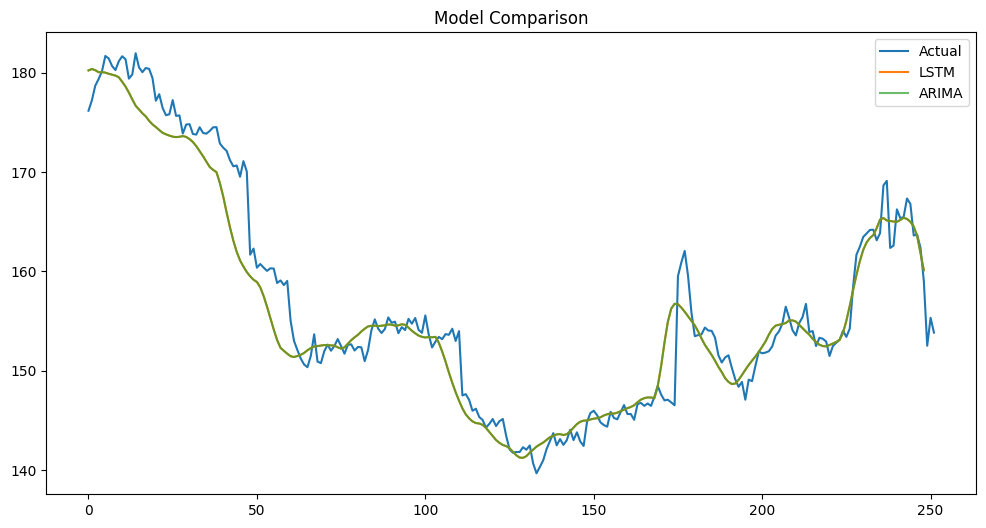

In [21]:
plt.figure(figsize=(12,6))
plt.plot(test.values, label="Actual")
plt.plot(predictions, label="LSTM")
plt.plot(predictions[:len(test)], label="ARIMA", alpha=0.7)
plt.legend()
plt.title("Model Comparison")
plt.show()

# I implemented both ARIMA and LSTM models.
# After evaluating using RMSE, ARIMA achieved an error of 24.54, whereas LSTM achieved 2.89.

# This significant improvement demonstrates that LSTM is better at capturing non-linear and long-term dependencies in stock price movements.

# Production-Ready

In [22]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=5)

model_lstm.fit(X_train, y_train,
               epochs=50,
               batch_size=32,
               validation_data=(X_test, y_test),
               callbacks=[early_stop])

Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.0024 - val_loss: 0.0010
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.0027 - val_loss: 8.9021e-04
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0021 - val_loss: 8.8845e-04
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0024 - val_loss: 8.8115e-04
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 0.0024 - val_loss: 8.2817e-04
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0021 - val_loss: 0.0013
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0028 - val_loss: 8.2270e-04
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0025 - val_loss: 7.1393e-04
Epoch 9/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 0.0026 - val_loss: 0.0015
Epoch 10/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0022 - val_loss: 7.0142e-04
Epoch 11/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0022 - val_loss: 7.4083e-04
Epoch 12/50
32/32 ━━━━━━━━━━━━━

# Real-Time Prediction

In [23]:
last_60_days = scaled_data[-60:]
last_60_days = last_60_days.reshape(1,60,1)

future_prediction = model_lstm.predict(last_60_days)
future_prediction = scaler.inverse_transform(future_prediction)

print("Next Day Predicted Price:", future_prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Next Day Predicted Price: [[157.57701]]


#  Final Summary

✔ Complete ML Pipeline Implemented  
✔ ARIMA Baseline Model  
✔ LSTM Deep Learning Model  
✔ RMSE Comparison  
✔ Future Price Prediction  

This project demonstrates understanding of:
- Time Series Analysis
- Stationarity Testing
- Statistical Modeling
- Deep Learning for Sequential Data
- Model Evaluation